In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ExpSineSquared
from sklearn.kernel_ridge import KernelRidge

In [18]:
df = pl.read_csv(Path("data/acoustic/tdoa/localization_disamb.csv"))
df = df.drop_nulls()

time = df["unix_time_us"].to_numpy() / 1e6
dwdt = df["angular_velocity"].to_numpy()

In [19]:
kernel_ridge = KernelRidge(kernel=ExpSineSquared())
kernel_ridge.fit(time.reshape(-1, 1), dwdt)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`. If an array is passed, penalties areassumed to be specific to the targets. Hence they must correspond innumber. See :ref:`ridge_regression` for formula.",1
,"kernel kernel: str or callable, default=""linear""Kernel mapping used internally. This parameter is directly passed to:class:`~sklearn.metrics.pairwise.pairwise_kernels`.If `kernel` is a string, it must be one of the metricsin `pairwise.PAIRWISE_KERNEL_FUNCTIONS` or ""precomputed"".If `kernel` is ""precomputed"", X is assumed to be a kernel matrix.Alternatively, if `kernel` is a callable function, it is called oneach pair of instances (rows) and the resulting value recorded. Thecallable should take two rows from X as input and return thecorresponding kernel value as a single number. This means thatcallables from :mod:`sklearn.metrics.pairwise` are not allowed, asthey operate on matrices, not single samples. Use the stringidentifying the kernel instead.",ExpSineSquare...periodicity=1)
,"gamma gamma: float, default=NoneGamma parameter for the RBF, laplacian, polynomial, exponential chi2and sigmoid kernels. Interpretation of the default value is left tothe kernel; see the documentation for sklearn.metrics.pairwise.Ignored by other kernels.",None
,"degree degree: float, default=3Degree of the polynomial kernel. Ignored by other kernels.",3
,"coef0 coef0: float, default=1Zero coefficient for polynomial and sigmoid kernels.Ignored by other kernels.",1
,"kernel_params kernel_params: dict, default=NoneAdditional parameters (keyword arguments) for kernel function passedas callable object.",None
,kernel__length_scale,1.0
,kernel__periodicity,1.0
,kernel__length_scale_bounds,"(1e-05, ...)"
,kernel__periodicity_bounds,"(1e-05, ...)"


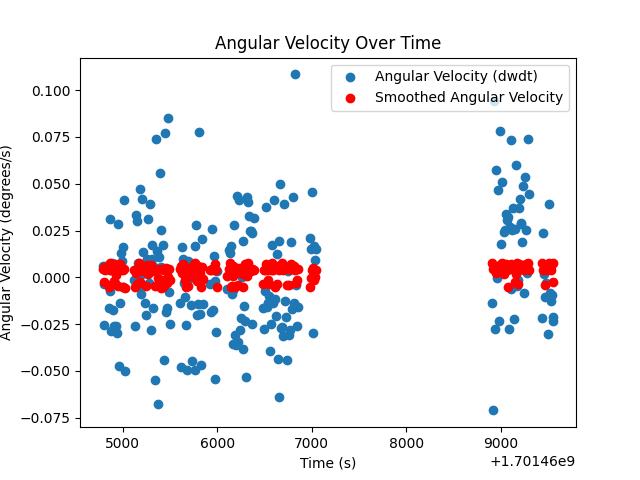

In [20]:
plt.figure()
plt.scatter(time, dwdt, label="Angular Velocity (dwdt)")
plt.scatter(time, kernel_ridge.predict(time.reshape(-1, 1)), label="Smoothed Angular Velocity", color="red")
plt.xlabel("Time (s)")
plt.ylabel("Angular Velocity (degrees/s)")
plt.title("Angular Velocity Over Time")
plt.legend()
plt.show()